# Customer Churn Prediction Using Machine Learning

**University of Lahore**  
**Artificial Intelligence - Assignment 1**

This notebook builds a machine learning system to predict whether a telecom customer is likely to churn.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

## 2. Load the Dataset

In [2]:
uploaded = files.upload()
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded.")

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded.


## 3. Understand the Dataset

In [3]:
print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe(include="all"))

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset shape:
(7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Basic statistics:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## 4. Important Columns

In [4]:
column_info = pd.DataFrame({
    "Column": [
        "customerID", "gender", "SeniorCitizen", "Partner", "Dependents",
        "tenure", "PhoneService", "MultipleLines", "InternetService",
        "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling",
        "PaymentMethod", "MonthlyCharges", "TotalCharges", "Churn"
    ],
    "Meaning": [
        "Unique identification number of the customer",
        "Gender of the customer",
        "Whether the customer is a senior citizen",
        "Whether the customer has a partner",
        "Whether the customer has dependents",
        "Number of months the customer has stayed",
        "Whether the customer has phone service",
        "Type of multiple line service",
        "Type of internet service",
        "Whether the customer has online security",
        "Whether the customer has online backup",
        "Whether the customer has device protection",
        "Whether the customer has technical support",
        "Whether the customer uses streaming TV",
        "Whether the customer uses streaming movies",
        "Type of customer contract",
        "Whether paperless billing is enabled",
        "Payment method used by the customer",
        "Monthly amount charged to the customer",
        "Total amount charged to the customer",
        "Whether the customer left the company"
    ]
})

display(column_info)

,Column,Meaning
0,customerID,Unique identification number of the customer
1,gender,Gender of the customer
2,SeniorCitizen,Whether the customer is a senior citizen
3,Partner,Whether the customer has a partner
4,Dependents,Whether the customer has dependents
5,tenure,Number of months the customer has stayed
6,PhoneService,Whether the customer has phone service
7,MultipleLines,Type of multiple line service
8,InternetService,Type of internet service
9,OnlineSecurity,Whether the customer has online security


## 5. Target Variable

In [5]:
print("Churn values:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 6. Check the Data for Problems

In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate records:
0


In [7]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU'
 '9763-GRSKD' '7469-LKBCI' '8091-TTVAX' '0280-XJGEX' '5129-JLPIS'
 '3655-SNQYZ' '8191-XWSZG' '9959-WOFKT' '4190-MFLUW' '4183-MYFRB']

gender:
['Female' 'Male']

SeniorCitizen:
[0 1]

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

tenure:
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30]

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mail

## 7. Clean the Data

In [8]:
print("TotalCharges type before conversion:")
print(df["TotalCharges"].dtype)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nTotalCharges type after conversion:")
print(df["TotalCharges"].dtype)

print("\nMissing TotalCharges values:")
print(df["TotalCharges"].isnull().sum())

TotalCharges type before conversion:
object

TotalCharges type after conversion:
float64

Missing TotalCharges values:
11


In [9]:
df = df.dropna(subset=["TotalCharges"])
df = df.drop_duplicates()

print("Dataset shape after cleaning:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate records after cleaning:")
print(df.duplicated().sum())

Dataset shape after cleaning:
(7032, 21)

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate records after cleaning:
0


## 8. Exploratory Data Analysis

### Churn Distribution

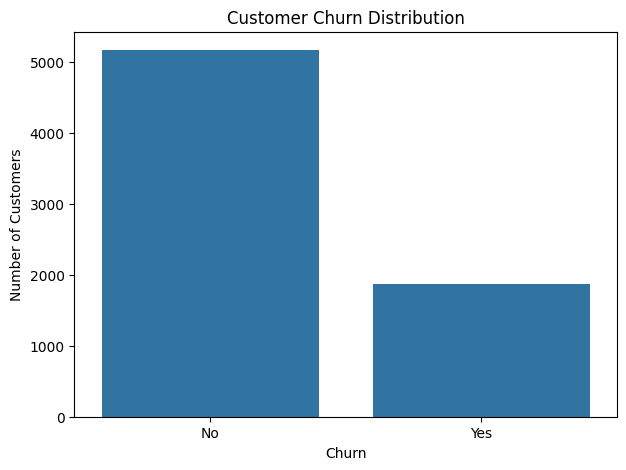

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Churn by Contract Type

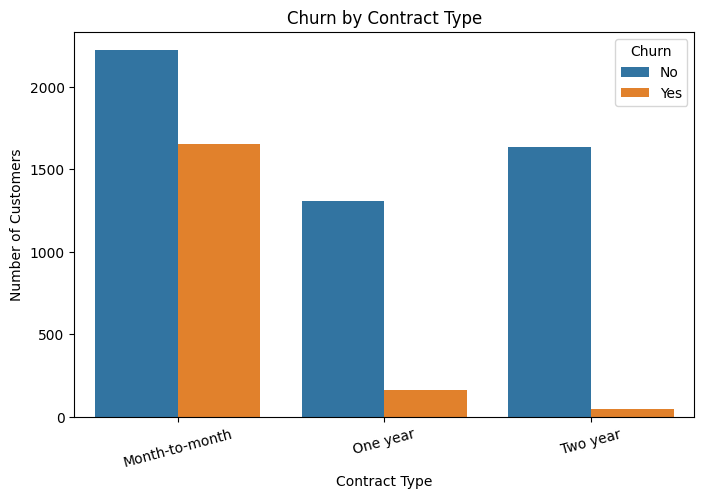

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

### Churn by Internet Service

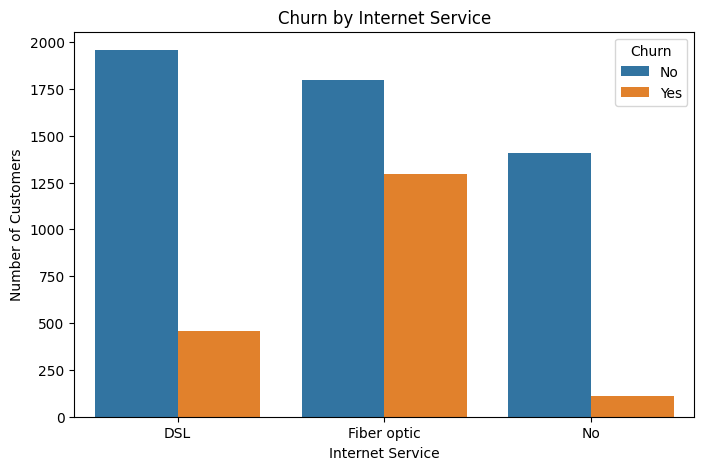

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

### Tenure vs Churn

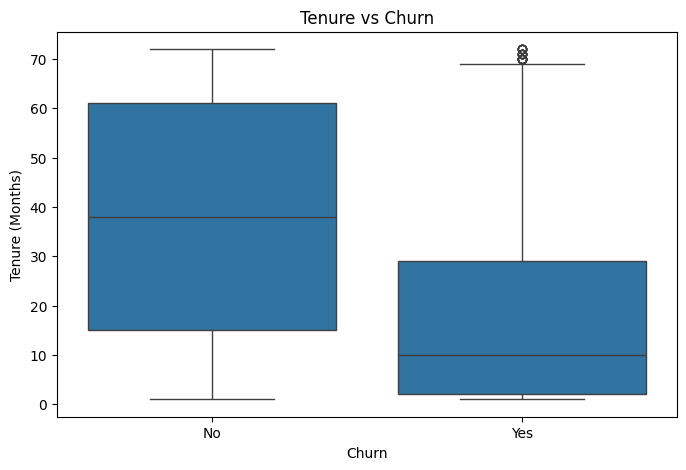

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### Monthly Charges vs Churn

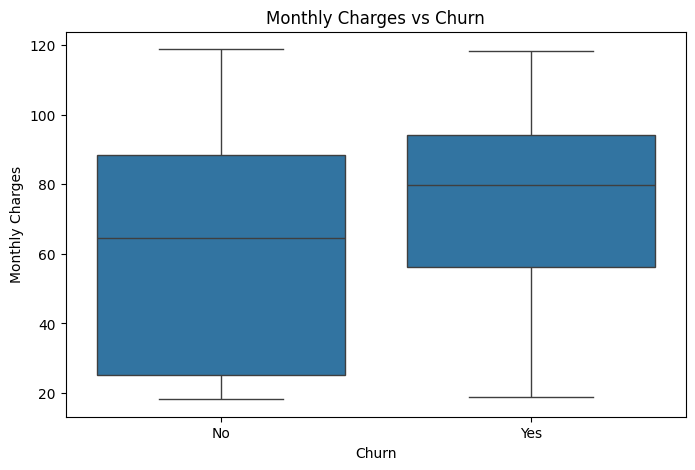

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### Total Charges vs Churn

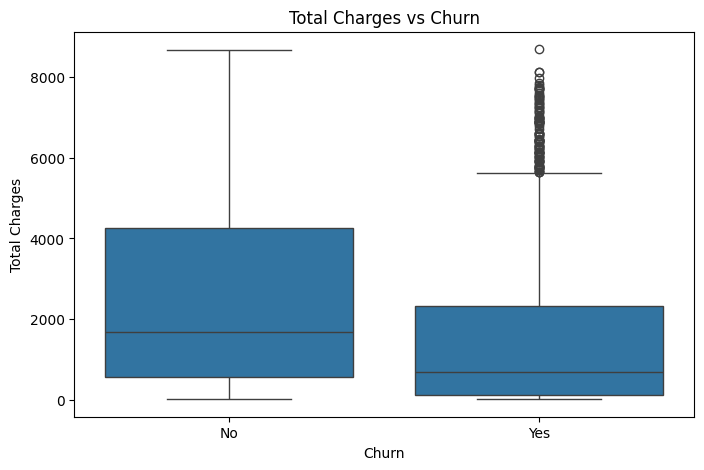

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

### Correlation Heatmap

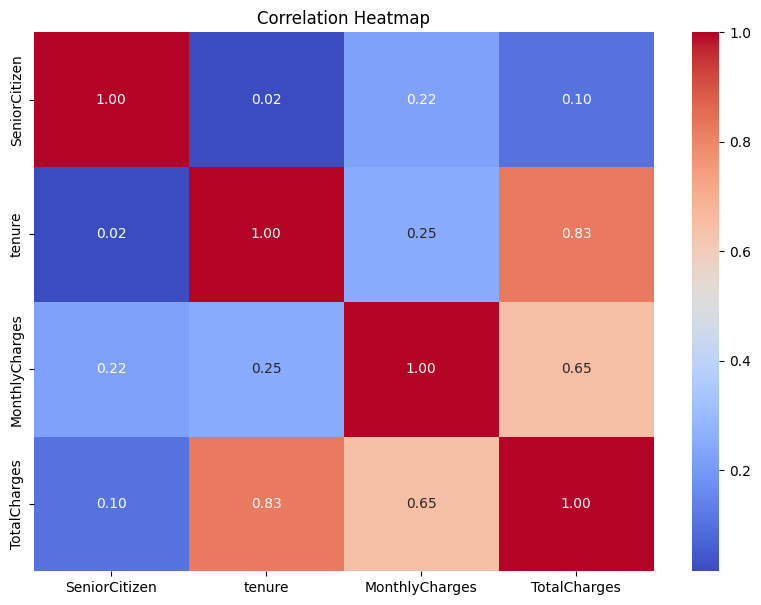

In [16]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 9. Feature Engineering and Encoding

In [17]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df = df.drop("customerID", axis=1)

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [18]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## 10. Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


## 11. Data Preprocessing

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 12. Logistic Regression

In [21]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1-Score :", logistic_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, target_names=["No Churn", "Churn"]))

Logistic Regression
-------------------
Accuracy : 0.7256574271499645
Precision: 0.4901315789473684
Recall   : 0.7967914438502673
F1-Score : 0.6069246435845214

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



### Logistic Regression Confusion Matrix

Confusion Matrix:
[[723 310]
 [ 76 298]]


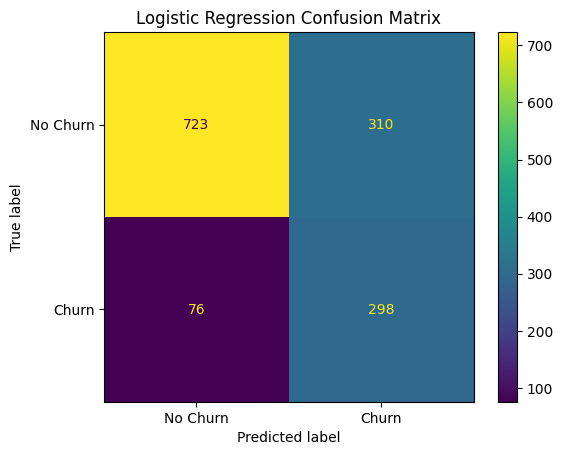

In [22]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=["No Churn", "Churn"])
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 13. Random Forest

In [23]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"))
    ]
)

random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))

Random Forest
-------------
Accuracy : 0.7839374555792467
Precision: 0.6232394366197183
Recall   : 0.4732620320855615
F1-Score : 0.5379939209726444

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1033
       Churn       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



### Random Forest Confusion Matrix

Confusion Matrix:
[[926 107]
 [197 177]]


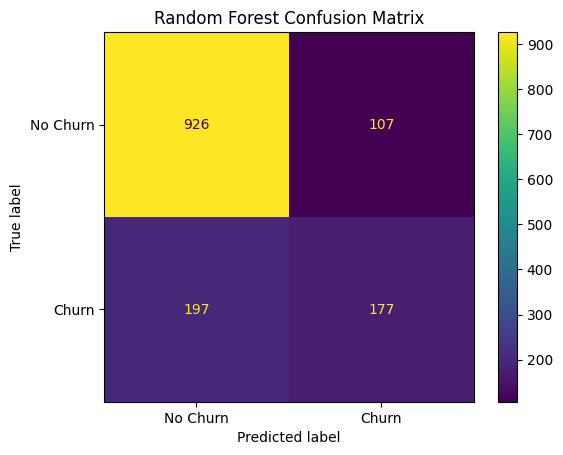

In [24]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Churn", "Churn"])
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

## 14. Compare the Models

In [25]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy],
    "Precision": [logistic_precision, rf_precision],
    "Recall": [logistic_recall, rf_recall],
    "F1-Score": [logistic_f1, rf_f1]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.725657,0.490132,0.796791,0.606925
1,Random Forest,0.783937,0.623239,0.473262,0.537994


### Model Comparison Graph

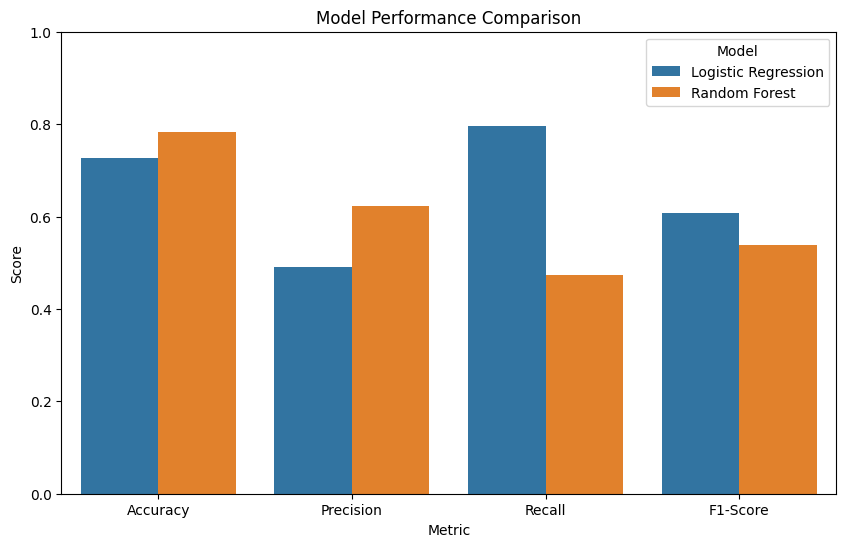

In [26]:
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.show()

## 15. Select the Final Model

In [27]:
if rf_f1 > logistic_f1:
    final_model = random_forest_model
    final_model_name = "Random Forest"
else:
    final_model = logistic_model
    final_model_name = "Logistic Regression"

print("Final selected model:", final_model_name)
print("The model was selected based on the higher F1-Score.")

Final selected model: Logistic Regression
The model was selected based on the higher F1-Score.


## 16. Customer Prediction

In [28]:
sample_customer = pd.DataFrame({
    "gender": ["Male"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [12],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.50],
    "TotalCharges": [1026.00]
})

print("Sample customer:")
display(sample_customer)

sample_prediction = final_model.predict(sample_customer)

if sample_prediction[0] == 1:
    print("Predicted Result: CHURN")
else:
    print("Predicted Result: NO CHURN")

Sample customer:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,No,12,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.5,1026.0


Predicted Result: CHURN


### Prediction Probability

In [29]:
sample_probability = final_model.predict_proba(sample_customer)

print("Probability of No Churn:", round(sample_probability[0][0] * 100, 2), "%")
print("Probability of Churn:", round(sample_probability[0][1] * 100, 2), "%")

Probability of No Churn: 13.21 %
Probability of Churn: 86.79 %


## 17. Final Results

In [30]:
print("FINAL ASSIGNMENT SUMMARY")
print("=========================")

print("Dataset size after cleaning:", df.shape)

print("\nLogistic Regression:")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))

print("\nRandom Forest:")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))

print("\nSelected Final Model:", final_model_name)

print("\nSample Customer Prediction:")

if sample_prediction[0] == 1:
    print("Churn = Yes")
else:
    print("Churn = No")

FINAL ASSIGNMENT SUMMARY
Dataset size after cleaning: (7032, 20)

Logistic Regression:
Accuracy : 0.7257
Precision: 0.4901
Recall   : 0.7968
F1-Score : 0.6069

Random Forest:
Accuracy : 0.7839
Precision: 0.6232
Recall   : 0.4733
F1-Score : 0.538

Selected Final Model: Logistic Regression

Sample Customer Prediction:
Churn = Yes


## Conclusion

The project completed the customer churn prediction pipeline. Two classification models were trained and evaluated using the same train-test split. Their performance was compared using accuracy, precision, recall, F1-score, and confusion matrices. The selected model was then used to predict churn for a sample customer.